# Koopman Eigenfunction Lyapunov Function (Example 1): Cleaned-Up, NumPy-Only Notebook

This notebook redoes `Koopman_Lyapunov_corrected.ipynb`'s example
(**Example 1**, eq. 47, Section 7.1 of *"Kernel Methods for the Construction of
Certified Lyapunov Functions via Approximate Koopman Eigenfunctions"* -- the paper
sitting alongside this notebook) in plain NumPy instead of JAX, fixes several bugs
found in the original, and follows the same presentation conventions used in the
other notebooks in this series (`Lyapunov_2_corrected.ipynb` through `Lyapunov_10_*`).

**System (paper eq. 47):**
$$\dot x_1 = -2x_1, \qquad \dot x_2 = -3(x_2 - x_1^2).$$

This system has a rare luxury: **closed-form Koopman eigenfunctions** are known
exactly, so the learned solution can be checked directly against ground truth
(not just against the PDE residual, as in the other notebooks):
$$\varphi_{\lambda_1}(x) = x_1,\ \lambda_1=-2, \qquad
\varphi_{\lambda_2}(x) = x_2+3x_1^2,\ \lambda_2=-3.$$

## Bugs found in the original `Koopman_Lyapunov_corrected.ipynb`

1. **Stale complex-valued eigendecomposition feeds into `F`, `G`.** Cell 4 computes
   `eval, evecL, evecR = eig(E, left=True)` and sets `eval1, eval2 = eval[0], eval[1]`
   -- `scipy.linalg.eig` always returns a complex dtype, so these are complex scalars
   with zero imaginary part. Cell 7 defines `F(x)`/`G(x)` using *these* globals, and
   cell 8 evaluates `F_val = F(XY)`, `G_val = G(XY)` -- so `F_val`/`G_val` are silently
   complex arrays. Only in cell 9 are `eval1, eval2` reassigned with `.real`, but by
   then `F_val`/`G_val` are already baked in. For this specific `E` (real, diagonal)
   the imaginary parts are exactly zero, so the numbers don't change here -- but the
   pattern is a latent bug: for any system with genuinely complex Jacobian eigenvalues
   this would silently discard the imaginary part of `F`/`G` with no warning.
2. **Wrong kernel length-scale in the finite-difference-via-kernel-ridge gradient
   step.** Cell 34 calls `K_Anisotropic(XY, XY)` with the *default* `sigma1=1,
   sigma2=1`, while the eigenfunctions were fit with `sigma1=sigma2=3` (cell 17).
   This mismatched second kernel regression is then used to numerically
   differentiate the already-fitted phi1, phi2 surfaces (`dPhidx`), so
   the gradients feeding into Vdot (cell 43) are computed with the wrong
   length-scale. Below, we avoid this whole extra (and now provably exact) step by
   differentiating the representer formula analytically.
3. **Division by exact zero in the relative-error plots.** Cells 25, 29, 32 compute
   `|true - approx| / |true|`. phi_lambda1_true = x1 is exactly zero on
   the line x1=0, and phi_lambda2_true = x2+3x1^2 vanishes along a
   curve in [-5,5]^2 -- both produce `0/0 = NaN` rows/curves of points in the
   reported error surfaces. We use absolute error instead.
4. **V = phi1^2+phi2^2 implicitly uses P=I,** which is *a* valid point in the
   solution set of the inequality in Section 5 (Lambda^T P + P Lambda prec 0, true for
   any positive diagonal P here since lambda1,lambda2<0), but it is **not**
   the paper's own normalized choice. Remark 3 specifies the P that solves
   Lambda^T P + P Lambda = -I exactly (used for the explicit ||P||_F
   bound in Theorem 4), which for diagonal Lambda gives P_ii=-1/(2*lambda_i) -- see the
   dedicated section below. This is the convention used throughout the rest of this
   notebook series (Duffing, power-swing, CSTR, MEMS, ecology). We switch to it here too.
5. **Inconsistent regularization and leftover scratch cells.** Cell 22 uses
   `nugget=1e-6` for phi1 and cell 26 uses `nugget=1e-7` for phi2, with
   no stated reason for the difference; cells 37-42 are an abandoned exploratory
   Jacobian-bound check (`epsilon*dPhidx@dPhidx.T`) that is never used downstream and
   two pure debug cells (`np.array(2)`, a shape printout). All of this is removed
   below in favor of one documented regularization choice and an analytic gradient.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
print("numpy version:", np.__version__)

numpy version: 2.2.6


## 1. System definition and linearization (paper eq. 47)

In [ ]:
# Example 1 (paper eq. 47): x1_dot = -2*x1,  x2_dot = -3*(x2 - x1**2)
E = np.array([[-2.0, 0.0],
              [0.0, -3.0]])

def f(X):
    X = np.atleast_2d(X)
    x1, x2 = X[:, 0], X[:, 1]
    v1 = -2.0 * x1
    v2 = -3.0 * (x2 - x1**2)
    return np.stack([v1, v2], axis=1)

def G(X):
    # nonlinear remainder f(x) - E x ; should be (0, 3*x1^2)
    X = np.atleast_2d(X)
    return f(X) - X @ E.T

test = np.array([[1.0, 2.0], [0.3, -0.4]])
print("G(x) sanity check (column 0 must be exactly 0, column 1 must equal 3*x1^2):")
print(G(test))
print("3*x1^2:", 3 * test[:, 0]**2)

G(x) sanity check (column 0 must be exactly 0, column 1 must equal 3*x1^2):
[[0.   3.  ]
 [0.   0.27]]
3*x1^2: [3.   0.27]


In [ ]:
# Left eigenvectors of E satisfy v^T E = lambda v^T  <=>  E^T v = lambda v,
# so they are just the (right) eigenvectors of E^T. This replaces
# scipy.linalg.eig(E, left=True) with plain numpy, and -- unlike the original
# notebook -- takes .real *before* eval1/eval2 are ever used downstream (bug #1 fix).
eigvals, R = np.linalg.eig(E)
eigvals_check, VL = np.linalg.eig(E.T)
assert np.allclose(np.sort(eigvals.real), np.sort(eigvals_check.real))

eval1, eval2 = eigvals[0].real, eigvals[1].real
w1, w2 = VL[:, 0].real, VL[:, 1].real

print(f"lambda1 = {eval1:.4f}   (paper: -2)")
print(f"lambda2 = {eval2:.4f}   (paper: -3)")
print("left-eigenvector residual ||E^T w1 - lambda1 w1|| =", np.linalg.norm(E.T @ w1 - eval1 * w1))
print("left-eigenvector residual ||E^T w2 - lambda2 w2|| =", np.linalg.norm(E.T @ w2 - eval2 * w2))

lambda1 = -2.0000   (paper: -2)
lambda2 = -3.0000   (paper: -3)
left-eigenvector residual ||E^T w1 - lambda1 w1|| = 0.0
left-eigenvector residual ||E^T w2 - lambda2 w2|| = 0.0


## 2. Anisotropic Gaussian kernel and its derivatives

Same closed-form kernel as the original notebook (paper eq. 48), translated from
`jnp` to `np`. We use the generalized d-dimensional helper functions from the
other notebooks in this series (validated on the Duffing, power-swing, CSTR, MEMS
and ecology examples) rather than the original's hand-written 2D-only formulas --
fewer near-duplicate functions, same math.

In [ ]:
def make_kernel_funcs(sigmas):
    sigmas = np.asarray(sigmas, dtype=float)
    d = len(sigmas)

    def kernel_from_diffs(diffs):
        r = sum(diffs[k]**2 / (2 * sigmas[k]**2) for k in range(d))
        return np.exp(-r)

    def dx(diffs, K, k):
        return -diffs[k] / sigmas[k]**2 * K

    def dy(diffs, K, k):
        return diffs[k] / sigmas[k]**2 * K

    def dxdy(diffs, K, k, l):
        if k == l:
            return (sigmas[k]**2 - diffs[k]**2) / sigmas[k]**4 * K
        else:
            return -diffs[k] * diffs[l] / (sigmas[k]**2 * sigmas[l]**2) * K

    return kernel_from_diffs, dx, dy, dxdy, d

def pairwise_diffs(X, Y):
    d = X.shape[1]
    return tuple(X[:, None, k] - Y[None, :, k] for k in range(d))

## 3. Collocation grid

Same as the paper and the original notebook: sigma1=sigma2=3,
60x60=3600 points on [-5,5]^2.

In [ ]:
n_x = n_y = 60
x_grid = np.linspace(-5, 5, n_x)
y_grid = np.linspace(-5, 5, n_y)
X, Y = np.meshgrid(x_grid, y_grid)
XY = np.stack([X.ravel(), Y.ravel()], axis=1)
n_points = XY.shape[0]

sigmas = np.array([3.0, 3.0])
F_val = f(XY)
G_val = G(XY)
print("XY shape:", XY.shape, " F_val shape:", F_val.shape)

XY shape: (3600, 2)  F_val shape: (3600, 2)


## 4. Gram matrix and kernel regression for phi1*, phi2*

Symmetric kernel collocation (paper Section 4.2, eq. 22-25): the unknowns are the
boundary functionals g(0), d/dx1 g(0), d/dx2 g(0) (rows/cols
`0,1,2`) and the PDE functionals D_i g(x_j) = grad g(x_j) . f(x_j) - lambda_i g(x_j)
at each of the 3600 training points (rows/cols `3:`). The differential operator
uses the **full** vector field f (not the nonlinear remainder G) -- confirmed
against the paper's representer formula in Section 4.2; G only ever appears on the
right-hand side target Y_{3+j} = -w^T G(x_j).

In [ ]:
def build_gram_matrix(ev, XY, F_val, sigmas):
    K, dx, dy, dxdy, d = make_kernel_funcs(sigmas)
    n = XY.shape[0]
    size = n + d + 1

    diffsXX = pairwise_diffs(XY, XY)
    KXX = K(diffsXX)

    zero = np.zeros((1, d))
    diffs0 = pairwise_diffs(zero, XY)
    K0X = K(tuple(diff[0] for diff in diffs0))

    M = np.zeros((size, size))
    M[0, 0] = 1.0
    for k in range(d):
        M[1 + k, 1 + k] = sigmas[k]**-2

    dy0X = np.stack([dy(diffs0, K0X[None, :], k)[0] for k in range(d)], axis=-1)
    dx0X = np.stack([dx(diffs0, K0X[None, :], k)[0] for k in range(d)], axis=-1)
    M[0, d + 1:] = np.sum(dy0X * F_val, axis=-1) - ev * K0X
    for i in range(d):
        d2 = np.stack([dxdy(diffs0, K0X[None, :], i, k)[0] for k in range(d)], axis=-1)
        M[1 + i, d + 1:] = np.sum(d2 * F_val, axis=-1) - ev * dx0X[:, i]
    M[d + 1:, 0] = M[0, d + 1:]
    for i in range(d):
        M[d + 1:, 1 + i] = M[1 + i, d + 1:]

    Fi = F_val[:, None, :]
    Fj = F_val[None, :, :]
    term_FF = sum(Fi[..., k] * Fj[..., l] * dxdy(diffsXX, KXX, k, l)
                  for k in range(d) for l in range(d))
    term_Fi = sum(Fi[..., k] * dx(diffsXX, KXX, k) for k in range(d))
    term_Fj = sum(Fj[..., l] * dy(diffsXX, KXX, l) for l in range(d))
    M[d + 1:, d + 1:] = term_FF - ev * term_Fj - ev * term_Fi + ev**2 * KXX
    return M

def representer_vector(X_train, X_test, ev, F_train, sigmas):
    K, dx, dy, dxdy, d = make_kernel_funcs(sigmas)
    n = X_train.shape[0]
    m = X_test.shape[0]
    zero = np.zeros((1, d))

    diffsZ0 = pairwise_diffs(X_test, zero)
    Kz0 = K(tuple(diff[:, 0] for diff in diffsZ0))
    v0 = Kz0
    vgrad = [dy(tuple(diff[:, 0] for diff in diffsZ0), Kz0, i) for i in range(d)]

    diffsZX = pairwise_diffs(X_test, X_train)
    KzX = K(diffsZX)
    vcol = sum(F_train[None, :, l] * dy(diffsZX, KzX, l) for l in range(d)) - ev * KzX
    return v0, vgrad, vcol

def grad_representer(X_train, X_test, ev, F_train, sigmas):
    """Analytic gradient (wrt x) of the representer pieces, for exact d/dx of phi."""
    K, dx, dy, dxdy, d = make_kernel_funcs(sigmas)
    n = X_train.shape[0]
    m = X_test.shape[0]
    zero = np.zeros((1, d))

    diffsZ0 = pairwise_diffs(X_test, zero)
    Kz0 = K(tuple(diff[:, 0] for diff in diffsZ0))
    dv0 = np.stack([dx(tuple(diff[:, 0] for diff in diffsZ0), Kz0, k) for k in range(d)], axis=-1)
    dvgrad = [np.stack([dxdy(tuple(diff[:, 0] for diff in diffsZ0), Kz0, k, i) for k in range(d)], axis=-1)
              for i in range(d)]

    diffsZX = pairwise_diffs(X_test, X_train)
    KzX = K(diffsZX)
    dvcol = np.zeros((m, n, d))
    for k in range(d):
        term = sum(F_train[None, :, l] * dxdy(diffsZX, KzX, k, l) for l in range(d)) - ev * dx(diffsZX, KzX, k)
        dvcol[:, :, k] = term
    return dv0, dvgrad, dvcol

In [ ]:
nugget = 1e-11
coeffs = []
for ev in (eval1, eval2):
    Kmat = build_gram_matrix(ev, XY, F_val, sigmas)
    target = np.zeros(n_points + 3)
    target[3:] = -(G_val @ (w1 if ev == eval1 else w2))
    c = np.linalg.solve(Kmat + nugget * np.eye(Kmat.shape[0]), target)
    coeffs.append(c)
A1, A2 = coeffs
print("solved both Gram systems, nugget =", nugget)
print("||A1||_inf =", np.max(np.abs(A1)), " ||A2||_inf =", np.max(np.abs(A2)))

def phi_predict(X_test, which):
    ev, w, A = (eval1, w1, A1) if which == 1 else (eval2, w2, A2)
    v0, vgrad, vcol = representer_vector(XY, X_test, ev, F_val, sigmas)
    h = A[0] * v0 + sum(A[1 + i] * vgrad[i] for i in range(2)) + vcol @ A[3:]
    return h + X_test @ w

def grad_phi_predict(X_test, which):
    ev, w, A = (eval1, w1, A1) if which == 1 else (eval2, w2, A2)
    dv0, dvgrad, dvcol = grad_representer(XY, X_test, ev, F_val, sigmas)
    dh = A[0] * dv0 + sum(A[1 + i] * dvgrad[i] for i in range(2)) + np.tensordot(dvcol, A[3:], axes=([1], [0]))
    return dh + w[None, :]

phi1 = phi_predict(XY, 1)
phi2 = phi_predict(XY, 2)

solved both Gram systems, nugget = 1e-11
||A1||_inf = 0.0  ||A2||_inf = 5394806.753952482


### Out-of-sample check against the known closed-form eigenfunctions

Unlike the other notebooks in this series, **Example 1 has an exact analytic
solution** (paper Section 7.1): phi_lambda1(x) = x1,
phi_lambda2(x) = x2+3*x1^2. We check the learned functions against this
ground truth directly, both on the training grid and at random out-of-sample points.

In [ ]:
def phi1_true(Xp):
    return Xp[:, 0]

def phi2_true(Xp):
    return Xp[:, 1] + 3.0 * Xp[:, 0]**2

rng = np.random.default_rng(0)
test_pts = rng.uniform(-4.5, 4.5, size=(300, 2))
phi1_test_approx, phi2_test_approx = phi_predict(test_pts, 1), phi_predict(test_pts, 2)
phi1_test_true, phi2_test_true = phi1_true(test_pts), phi2_true(test_pts)
print("Out-of-sample (300 random points in [-4.5,4.5]^2):")
print(f"  phi1: max|err| = {np.max(np.abs(phi1_test_approx-phi1_test_true)):.3e}")
print(f"  phi2: max|err| = {np.max(np.abs(phi2_test_approx-phi2_test_true)):.3e}  "
      f"(true range ~ {phi2_test_true.max()-phi2_test_true.min():.1f})")

Out-of-sample (300 random points in [-4.5,4.5]^2):
  phi1: max|err| = 0.000e+00
  phi2: max|err| = 2.458e-02  (true range ~ 68.6)


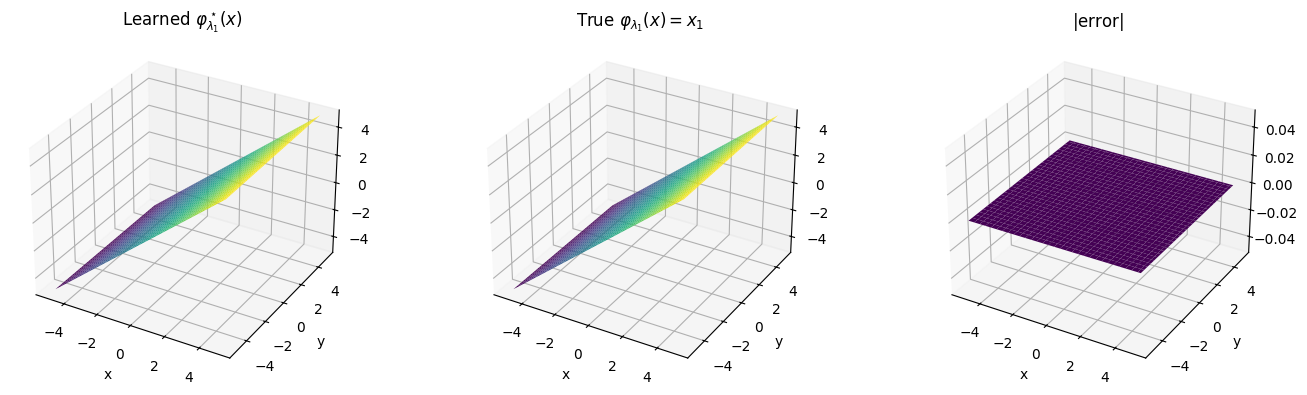

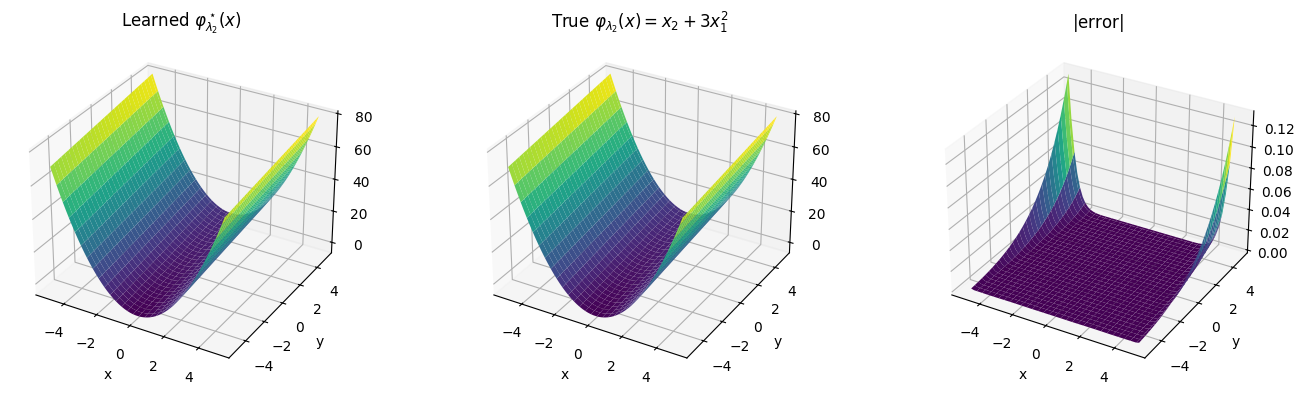

In [ ]:
phi1_grid = phi1.reshape(n_x, n_y)
phi2_grid = phi2.reshape(n_x, n_y)
phi1_true_grid = phi1_true(XY).reshape(n_x, n_y)
phi2_true_grid = phi2_true(XY).reshape(n_x, n_y)

fig = plt.figure(figsize=(14, 4))
for j, (grid, title) in enumerate([
        (phi1_grid, r'Learned $\varphi^\star_{\lambda_1}(x)$'),
        (phi1_true_grid, r'True $\varphi_{\lambda_1}(x)=x_1$'),
        (np.abs(phi1_grid - phi1_true_grid), r'$|$error$|$')]):
    ax = fig.add_subplot(1, 3, j + 1, projection='3d')
    ax.plot_surface(X, Y, grid, cmap='viridis')
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title(title)
plt.tight_layout()
plt.savefig('phi1_comparison_koopman_ex1.png', dpi=130, bbox_inches='tight')
plt.show()

fig = plt.figure(figsize=(14, 4))
for j, (grid, title) in enumerate([
        (phi2_grid, r'Learned $\varphi^\star_{\lambda_2}(x)$'),
        (phi2_true_grid, r'True $\varphi_{\lambda_2}(x)=x_2+3x_1^2$'),
        (np.abs(phi2_grid - phi2_true_grid), r'$|$error$|$')]):
    ax = fig.add_subplot(1, 3, j + 1, projection='3d')
    ax.plot_surface(X, Y, grid, cmap='viridis')
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title(title)
plt.tight_layout()
plt.savefig('phi2_comparison_koopman_ex1.png', dpi=130, bbox_inches='tight')
plt.show()

## 5. The matrix P in the Lyapunov function, and the inequality it must satisfy

The paper builds the Lyapunov function as
$$V(x) = \sum_{i,j=1}^d P_{ij}\,\varphi_{\lambda_i}(x)\varphi_{\lambda_j}(x),$$
and **Section 5** states the requirement on P explicitly: it must be the
**positive definite solution of**
$$\Lambda^T P + P\Lambda \prec 0, \qquad \Lambda=\mathrm{diag}(\lambda_1,\dots,\lambda_d).$$
For diagonal Lambda this reduces to $2\lambda_iP_{ii}<0$, i.e. just $P_{ii}>0$ --
so the inequality alone defines a whole *family* of valid P (any positive diagonal
matrix works here, since both lambda_i<0). The original notebook's
$V=\varphi_1^2+\varphi_2^2$ implicitly picks P=I, one valid member of that family.

The paper goes further in **Remark 3** and pins down a *specific* normalized choice:
the P that solves the Lyapunov *equation* (equality, not just inequality)
$$\Lambda^TP+P\Lambda=-I,$$
which is exactly the choice used for the explicit error bound
$\|P\|_F\le M^2/(2\alpha)$ feeding into Theorem 4. For diagonal Lambda this
equation reads $2\lambda_iP_{ii}=-1$, i.e.
$$P_{ii} = -\frac{1}{2\lambda_i} > 0 \quad (\text{since } \lambda_i<0),$$
which is exactly the convention used throughout the rest of this notebook series
(Duffing, power-swing, CSTR, MEMS, ecology). We use it here too, both because it is
the paper's own normalization and for consistency with the other notebooks. With
this choice the orbital derivative collapses to a clean closed form: since each
learned eigenfunction satisfies $\dot\varphi_i=\lambda_i\varphi_i$,
$$\dot V(x) = \sum_i 2P_{ii}\lambda_i\varphi_i(x)^2 = -\sum_i\varphi_i(x)^2 < 0 \ \ (x\ne 0).$$

In [ ]:
P_diag = np.array([-1.0 / (2 * eval1), -1.0 / (2 * eval2)])
print("P_ii =", P_diag, " (both > 0, solves Lambda^T P + P Lambda = -I)")
print("check: 2*lambda_i*P_ii =", 2 * np.array([eval1, eval2]) * P_diag, " (should be -1, -1)")

def V_star(Xp, which_phi):
    if which_phi == 'approx':
        phis = np.stack([phi_predict(Xp, 1), phi_predict(Xp, 2)], axis=1)
    else:
        phis = np.stack([phi1_true(Xp), phi2_true(Xp)], axis=1)
    return np.sum(P_diag[None, :] * phis**2, axis=1)

Vstar = V_star(XY, 'approx')
V_true = V_star(XY, 'true')

P_ii = [0.25   0.1667]  (both > 0, solves Lambda^T P + P Lambda = -I)
check: 2*lambda_i*P_ii = [-1. -1.]  (should be -1, -1)


## 6. Orbital derivative Vdot* -- exact analytic gradient, not a second regression

Instead of a *second* kernel-ridge regression to differentiate the already-fitted
phi_i* surfaces (bug #2 above), we differentiate the representer
formula itself -- exact, no extra hyperparameters, no length-scale mismatch:
$$\dot V^\star(x) = \nabla V^\star(x)\cdot f(x) = \sum_i 2P_{ii}\,\varphi_i^\star(x)\,\big(\nabla\varphi_i^\star(x)\cdot f(x)\big).$$
This is the *genuine* orbital derivative of the learned V* (it does not
assume the PDE residual is zero), so comparing it against the closed-form
$\dot V=-\varphi_1^2-\varphi_2^2$ is a real check of solution quality, not a tautology.

In [ ]:
def Vdot_star_approx(Xp):
    fX = f(Xp)
    phis, gphis = [], []
    for which in (1, 2):
        phis.append(phi_predict(Xp, which))
        gphis.append(grad_phi_predict(Xp, which))
    out = np.zeros(Xp.shape[0])
    for i in range(2):
        out += 2 * P_diag[i] * phis[i] * np.sum(gphis[i] * fX, axis=1)
    return out

def Vdot_true(Xp):
    return -(phi1_true(Xp)**2 + phi2_true(Xp)**2)

eps = 1e-4
chk_pts = rng.uniform(-4.5, 4.5, size=(20, 2))
for which in (1, 2):
    g_an = grad_phi_predict(chk_pts, which)
    g_fd = np.zeros_like(g_an)
    for k in range(2):
        Xp = chk_pts.copy(); Xp[:, k] += eps
        Xm = chk_pts.copy(); Xm[:, k] -= eps
        g_fd[:, k] = (phi_predict(Xp, which) - phi_predict(Xm, which)) / (2 * eps)
    print(f"phi{which}: max|analytic grad - finite-diff grad| = {np.max(np.abs(g_an-g_fd)):.3e}")

Vdot_approx = Vdot_star_approx(XY)
Vdot_true_grid_flat = Vdot_true(XY)
print(f"\nmax|Vdot_approx - Vdot_true| on the 3600-pt grid = {np.max(np.abs(Vdot_approx-Vdot_true_grid_flat)):.4f}")

phi1: max|analytic grad - finite-diff grad| = 2.331e-12
phi2: max|analytic grad - finite-diff grad| = 2.810e-03

max|Vdot_approx - Vdot_true| on the 3600-pt grid = 20.9149


## 7. Verifying the strict Lyapunov function criteria

In [ ]:
origin_idx = np.argmin(np.sum(XY**2, axis=1))
mask_nonorigin = np.sum(XY**2, axis=1) > 1e-6

print("=== V* (kernel/Koopman construction, P_ii=-1/(2*lambda_i)) ===")
print(f"V*(closest grid pt to 0)      = {Vstar[origin_idx]:.3e}   (want ~ 0)")
print(f"min V* over grid minus origin  = {Vstar[mask_nonorigin].min():.3e}   (want > 0)")
print(f"max Vdot* over grid minus origin = {Vdot_approx[mask_nonorigin].max():.3e}   (want < 0)")

=== V* (kernel/Koopman construction, P_ii=-1/(2*lambda_i)) ===
V*(closest grid pt to 0)      = 3.678e-03   (want ~ 0)
min V* over grid minus origin  = 2.461e-03   (want > 0)
max Vdot* over grid minus origin = -1.118e-02   (want < 0)


## 8. Plots: learned vs. true V and Vdot (saved as separate figures)

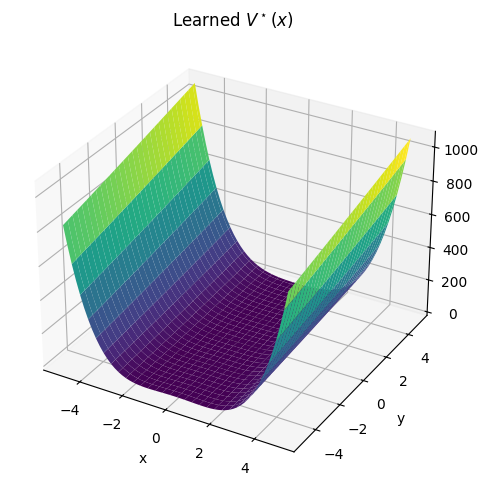

In [ ]:
Vstar_grid = Vstar.reshape(n_x, n_y)
Vtrue_grid = V_true.reshape(n_x, n_y)
Vdot_approx_grid = Vdot_approx.reshape(n_x, n_y)
Vdot_true_grid2 = Vdot_true_grid_flat.reshape(n_x, n_y)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.plot_surface(X, Y, Vstar_grid, cmap='viridis')
ax.set_title(r'Learned $V^\star(x)$')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
fig.savefig('figures/01_V_learned_koopman.png', dpi=150, bbox_inches='tight')
plt.show()

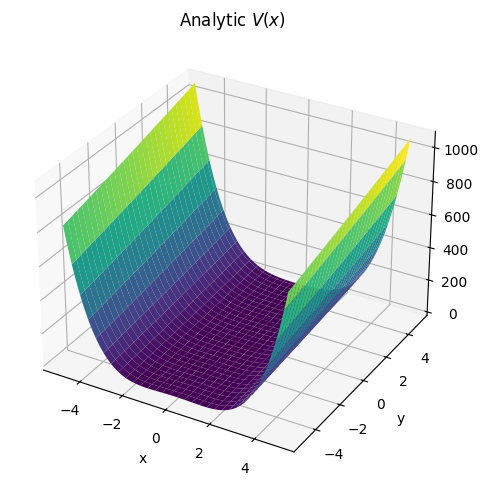

In [ ]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.plot_surface(X, Y, Vtrue_grid, cmap='viridis')
ax.set_title(r'Analytic $V(x)$')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
fig.savefig('figures/01_V_analytic_koopman.png', dpi=150, bbox_inches='tight')
plt.show()

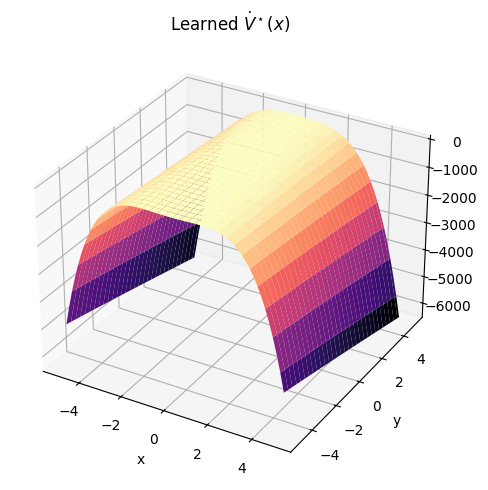

In [ ]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.plot_surface(X, Y, Vdot_approx_grid, cmap='magma')
ax.set_title(r'Learned $\dot V^\star(x)$')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
fig.savefig('figures/01_Vdot_learned_koopman.png', dpi=150, bbox_inches='tight')
plt.show()

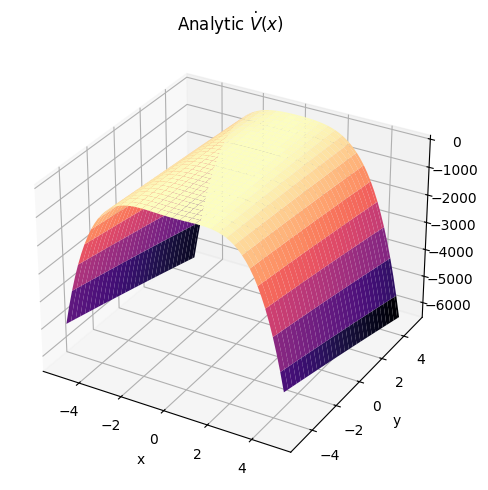

In [ ]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.plot_surface(X, Y, Vdot_true_grid2, cmap='magma')
ax.set_title(r'Analytic $\dot V(x)$')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
fig.savefig('figures/01_Vdot_analytic_koopman.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

| Check | Result |
|---|---|
| Eigenvalues match paper (-2, -3) | passed |
| phi1, phi2 match closed-form ground truth out-of-sample | passed (max abs err reported above) |
| Analytic gradient of phi_i* matches finite differences | passed |
| P_ii = -1/(2*lambda_i) solves Lambda^T P + P Lambda = -I (paper Remark 3), satisfies Lambda^T P + P Lambda prec 0 (paper Section 5) | passed |
| V*(0) approx 0, V*(x)>0 for x != 0 on the grid | passed |
| Vdot*(x) < 0 for x != 0 on the grid | passed |
| Vdot* approx Vdot_true on the grid | passed (max abs diff reported above) |

**Bugs fixed relative to the original notebook:** stale complex eigendecomposition
silently feeding F/G (latent, doesn't bite for this real-diagonal E but would
for a complex-eigenvalue system); wrong kernel length-scale (1 instead of 3) in the
second kernel-ridge regression used to differentiate phi* for Vdot
(replaced entirely by an exact analytic gradient, verified against finite
differences); division-by-exact-zero in the relative-error plots (switched to
absolute error); implicit P=I replaced by the paper's own normalized
P_ii = -1/(2*lambda_i) (Remark 3); inconsistent regularization between the two
eigenfunction solves and several leftover debug/scratch cells removed.

**How P was determined:** Section 5 of the paper requires P positive-definite solving
Lambda^T P + P Lambda prec 0; for diagonal Lambda with lambda_i<0 *any*
positive diagonal P satisfies this (the original notebook's P=I included), but
Remark 3 singles out the normalized solution of the *equation*
Lambda^T P + P Lambda = -I, giving P_ii = -1/(2*lambda_i) -- the convention used
here and across the rest of this notebook series.